Let's start simple.

We start with the simplest case, a Schwartzschild black hole, with a typical newtonian inverse radial potential, $\displaystyle -\frac{1}{r}$. 

That is
$$
\Phi_\text{bh} = -\frac{GM_\text{bh}}{r}
$$

That's it, we don't consider other masses, just this blackhole.

We assume a star with mass $M_\star$ to enter at a parabolic trajectory, i.e., $E_\star=0$,
which touches the tidal radius $R_t$ precisely (i.e., penetration factor $\delta= \frac{R_t}{R_p} = 1$).  






In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from matplotlib.patches import FancyArrowPatch
plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

fsize = 12
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": fsize,
    "axes.titlesize": fsize,
    "axes.labelsize": fsize,
    "xtick.labelsize": fsize,
    "ytick.labelsize": fsize,
    "legend.fontsize": fsize,
})

def blob(pos, scale=1, phase=0, a = 0.15, b = 0.10, c = 0.07, resolution = 720):
    theta = np.linspace(0,2*np.pi,resolution)
    r = scale * (
        1
        + a * np.sin(2*theta + phase)
        + b * np.cos(3*theta - phase)
        + c * np.sin(5*theta + 0.5*phase)
    )
    return r*np.cos(theta) + pos[0], r*np.sin(theta) + pos[1]

def draw_axis(
    pos,
    axisname=None,
    azimuth=0,
    elevation=30,
    axislen=1,
    labeldist=1.3
):

    # Degrees -> radians
    azimuth = np.deg2rad(azimuth)
    elevation = np.deg2rad(elevation)

    # Original 3D Cartesian basis
    axes3d = np.array([
        [1, 0, 0],   # x
        [0, 1, 0],   # y
        [0, 0, 1]    # z
    ])

    # Orthographic projection

    azimuth_transform = np.array([
        [np.cos(azimuth), -np.sin(azimuth), 0],
        [np.sin(azimuth),  np.cos(azimuth), 0],
        [ 0             ,  0              , 1]
    ])

    elevation_transform = np.array([
        [1, 0                ,  0               ],
        [0, np.cos(elevation), -np.sin(elevation)],
        [0, np.sin(elevation),  np.cos(elevation)]
    ])

    drop_y = np.array([
        [1, 0, 0],
        [0, 0, 1]
    ])

    P = drop_y @ elevation_transform @ azimuth_transform 
    # Project 3D basis -> 2D
    axes2d = P @ axes3d 
    # Labels
    if axisname is None:
        labels = [
            r'$\mathbf{1}$',
            r'$\mathbf{2}$',
            r'$\mathbf{n}$'
        ]
    else:
        labels = axisname

    for ax, label in zip(axes2d.T, labels):

        plt.arrow(
            *pos,
            axislen * ax[0],
            axislen * ax[1],
            color='k',
            linewidth=1,
            head_width=0.05,
            head_length=0.1,
            length_includes_head=True
        )

        plt.annotate(
            label,
            [
                pos[0] + labeldist * axislen * ax[0],
                pos[1] + labeldist * axislen * ax[1]
            ],
            ha='center',
            va='center'
        )

def map_arrow(pt1, pt2, pt3, maplabel,
              label1gap=0.3, label2gap=0.3, mapgap=0.3,
              lw=0.75, head_width=0.05, head_length=0.1):

    def circle_from_3pts(p1, p2, p3):

        cross = ((p2[0] - p1[0]) * (p3[1] - p1[1])
               - (p2[1] - p1[1]) * (p3[0] - p1[0]))

        if abs(cross) < 1e-12:
            return None, None

        x1, y1 = p1
        x2, y2 = p2
        x3, y3 = p3

        D = 2 * (
            x1 * (y2 - y3)
            + x2 * (y3 - y1)
            + x3 * (y1 - y2)
        )

        Ux = (
            (x1**2 + y1**2) * (y2 - y3)
            + (x2**2 + y2**2) * (y3 - y1)
            + (x3**2 + y3**2) * (y1 - y2)
        ) / D

        Uy = (
            (x1**2 + y1**2) * (x3 - x2)
            + (x2**2 + y2**2) * (x1 - x3)
            + (x3**2 + y3**2) * (x2 - x1)
        ) / D

        center = np.array([Ux, Uy])
        radius = np.linalg.norm(p1 - center)

        return center, radius

    center, radius = circle_from_3pts(pt1, pt2, pt3)

    # ------------------------------------------------------------
    # Collinear case
    # ------------------------------------------------------------
    if center is None:

        v1 = pt2 - pt1
        v1 /= np.linalg.norm(v1)

        v2 = pt3 - pt2
        v2 /= np.linalg.norm(v2)

        start1 = pt1 + label1gap * v1
        end1   = pt2 - mapgap * v1

        start2 = pt2 + mapgap * v2
        end2   = pt3 - label2gap * v2

        plt.plot(
            [start1[0], end1[0]],
            [start1[1], end1[1]],
            'k-', lw=lw
        )

        plt.plot(
            [start2[0], end2[0]],
            [start2[1], end2[1]],
            'k-', lw=lw
        )

        for start, end in [(start1, end1), (start2, end2)]:
            dx = end[0] - start[0]
            dy = end[1] - start[1]

            plt.arrow(
                start[0], start[1],
                dx, dy,
                head_width=head_width,
                head_length=head_length,
                fc='k',
                ec='k',
                length_includes_head=True
            )

        plt.annotate(
            maplabel,
            pt2,
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold'
        )
        return

    

C:\Users\verci\AppData\Local\Temp\ipykernel_5940\12492587.py:6: RuntimeWarning: divide by zero encountered in power
  mdot = a * T**(-5/3) - b * T**(-3)
C:\Users\verci\AppData\Local\Temp\ipykernel_5940\12492587.py:6: RuntimeWarning: invalid value encountered in subtract
  mdot = a * T**(-5/3) - b * T**(-3)


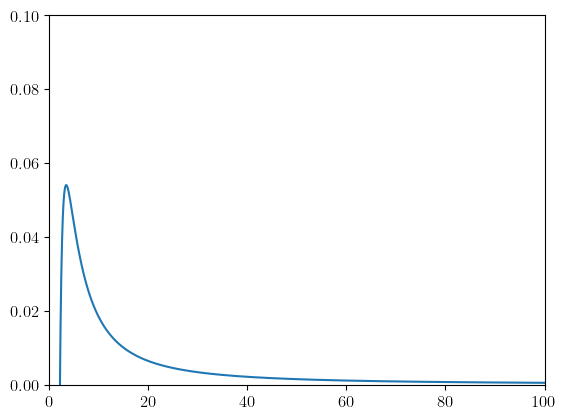

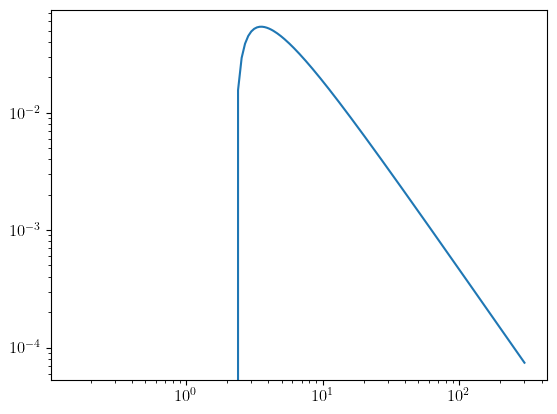

In [31]:


T = np.linspace(0,300,2000)

a = 1
b = 3

mdot = a * T**(-5/3) - b * T**(-3)

plt.plot(T, mdot)
plt.ylim(0,0.1)
plt.xlim(0,100)
plt.show()

plt.loglog(T,mdot) 
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


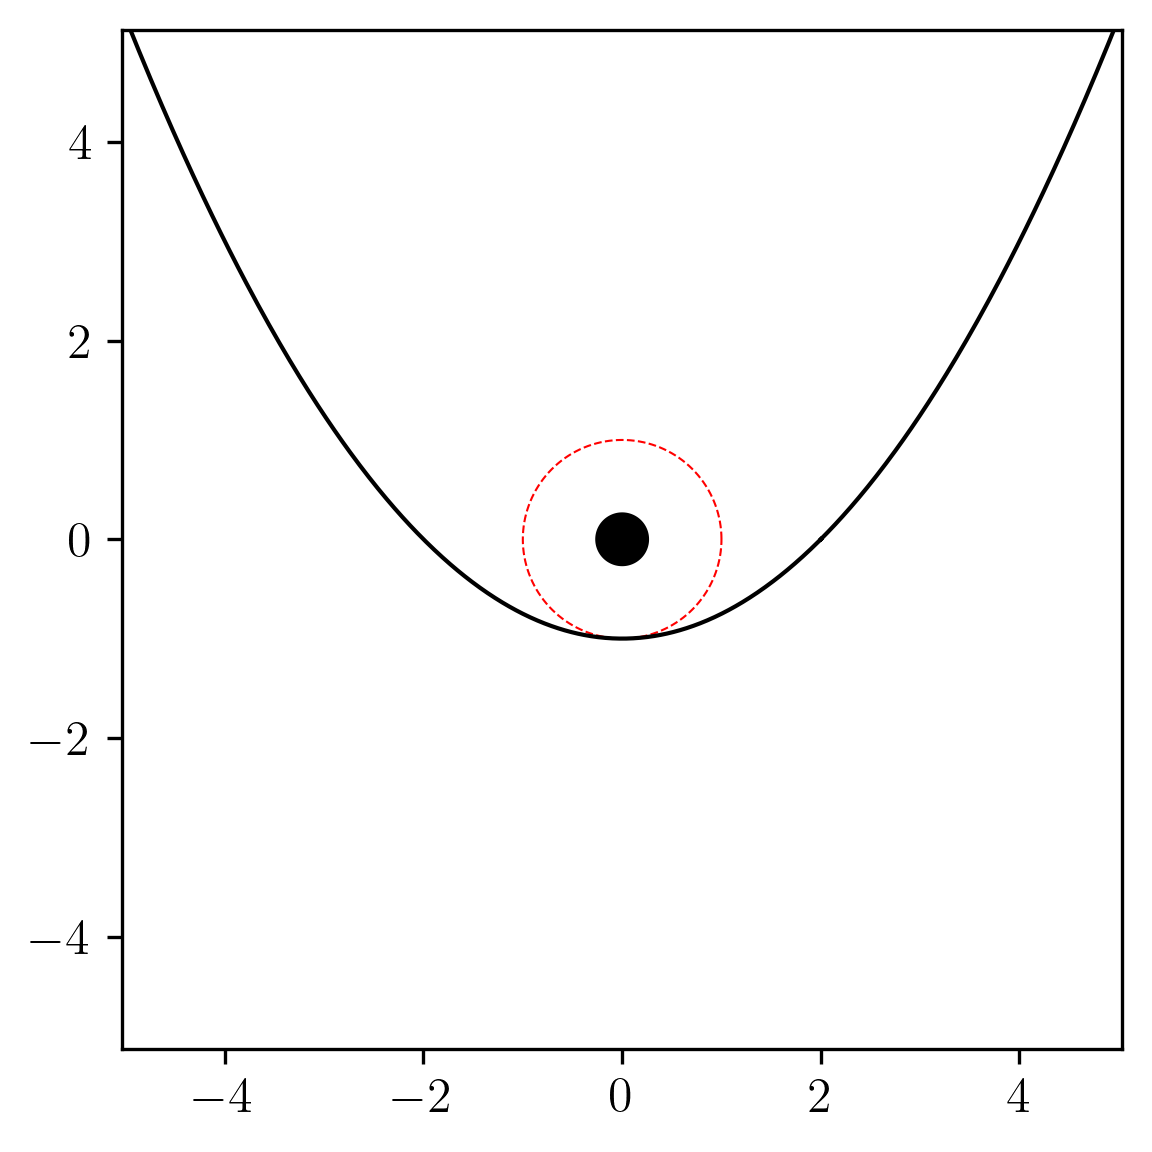

In [28]:
plt.figure(figsize = (4,4), dpi = 300)
plt.axis('equal')

bh = np.array([0,0])

theta = np.linspace(0, 2*np.pi, 720)

rbh = 0.25
bhr = rbh * np.array([
    np.cos(theta),
    np.sin(theta)
])

rt = np.array([
    np.cos(theta),
    np.sin(theta)
])

# FIX: Parabola opening upward: r = p/(1 - sin(theta))
p = 2  # focal parameter
r_trj = p / (1 - np.cos(theta - np.pi/2))
trj = r_trj * np.array([
    np.cos(theta),
    np.sin(theta)
])

plt.plot(*rt, 'r--', lw = 0.5 )
plt.plot(*trj, 'k-', lw= 1)
plt.fill(*bhr, color = 'k')

plt.xlim(-5,5)
plt.ylim(-5,5)
plt.tight_layout()
plt.show()